# Sales Predictor

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import seaborn as sns

In [2]:
myData = pd.read_csv("Advertising.csv")
print(myData)

        TV  radio  newspaper  sales
0    230.1   37.8       69.2   22.1
1     44.5   39.3       45.1   10.4
2     17.2   45.9       69.3    9.3
3    151.5   41.3       58.5   18.5
4    180.8   10.8       58.4   12.9
..     ...    ...        ...    ...
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1    9.7
197  177.0    9.3        6.4   12.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   13.4

[200 rows x 4 columns]


In [3]:
myData.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
tvAd = myData["TV"]
tvAd

0      230.1
1       44.5
2       17.2
3      151.5
4      180.8
       ...  
195     38.2
196     94.2
197    177.0
198    283.6
199    232.1
Name: TV, Length: 200, dtype: float64

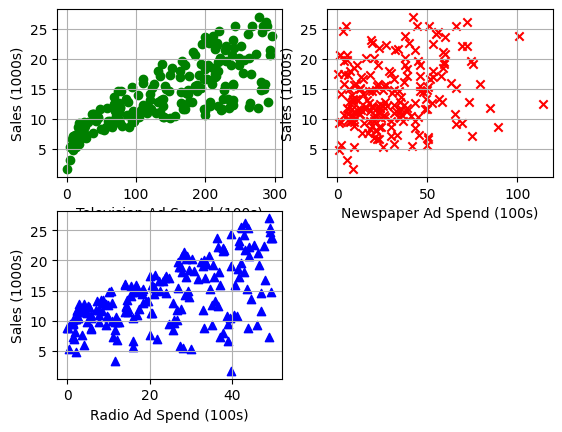

In [5]:
plt.subplot(2, 2, 1)
plt.scatter(tvAd, myData["sales"], color='green', marker='o', label='Television')
plt.ylabel("Sales (1000s)")
plt.xlabel("Television Ad Spend (100s)")
plt.grid()

plt.subplot(2, 2, 2)
plt.scatter(myData["newspaper"], myData["sales"], color='red', marker='x', label='Newspaper')
plt.ylabel("Sales (1000s)")
plt.xlabel("Newspaper Ad Spend (100s)")
plt.grid()

plt.subplot(2, 2, 3)
plt.scatter(myData["radio"], myData["sales"], color='blue', marker='^', label='Radio')
plt.ylabel("Sales (1000s)")
plt.xlabel("Radio Ad Spend (100s)")
plt.grid()

In [6]:
trainData, testData = train_test_split(myData, test_size=0.5, random_state=42)

In [7]:
tvLm = smf.ols(formula= "sales ~ TV", data = trainData).fit()
tvLm.summary()



salesPredict = tvLm.predict(testData)
tvLm.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.541
Method:                 Least Squares   F-statistic:                     117.7
Date:                Sat, 16 May 2026   Prob (F-statistic):           1.75e-18
Time:                        18:17:48   Log-Likelihood:                -268.23
No. Observations:                 100   AIC:                             540.5
Df Residuals:                      98   BIC:                             545.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.0428      0.775      9.082      0.000       5.504       8.582
TV             0.0473      0.004     10.850      0.000       0.039       0.056
==============================================================================
Omnibus:                        3.094   Durbin-Watson:                   2.125
Prob(Omnibus):                  0.213   Jarque-Bera (JB):                1.891
Skew:                          -0.058   Prob(JB):                        0.389
Kurtosis:                       2.336   Cond. No.                         386.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

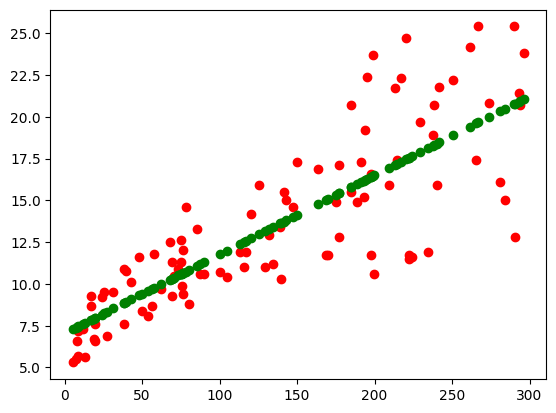

In [8]:
plt.scatter(testData['TV'], testData['sales'], color = 'red')
plt.scatter(testData['TV'], salesPredict, color = 'green')

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.541
Method:                 Least Squares   F-statistic:                     117.7
Date:                Sat, 16 May 2026   Prob (F-statistic):           1.75e-18
Time:                        18:19:49   Log-Likelihood:                -268.23
No. Observations:                 100   AIC:                             540.5
Df Residuals:                      98   BIC:                             545.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.0428      0.775      9.082      0.000       5.504       8.582
TV             0.0473      0.004     10.850      0.000       0.039       0.056
==============================================================================
Omnibus:                        3.094   Durbin-Watson:                   2.125
Prob(Omnibus):                  0.213   Jarque-Bera (JB):                1.891
Skew:                          -0.058   Prob(JB):                        0.389
Kurtosis:                       2.336   Cond. No.                         386.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

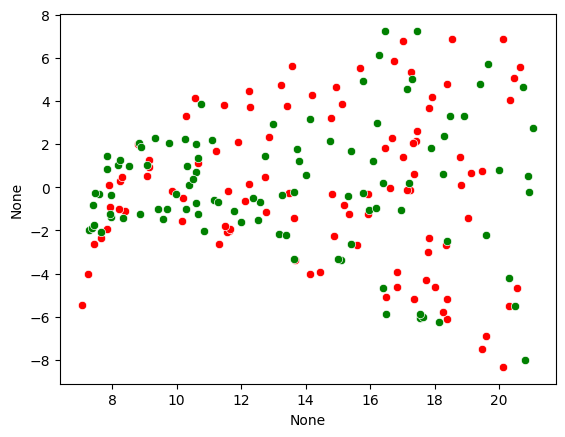

In [13]:
tvLm = smf.ols(formula= "sales ~ TV", data = trainData).fit()
tvLm.summary()

testPredict = tvLm.predict(testData)
trainPredict = tvLm.predict(trainData)
trainResiduals = trainData["sales"]-trainPredict
testResiduals = testData["sales"]-testPredict
tvLm.summary()
sns.scatterplot(x=trainPredict, y=trainResiduals, color = 'red')
sns.scatterplot(x=testPredict, y=testResiduals, color = 'green')
tvLm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     13.22
Date:                Sat, 16 May 2026   Prob (F-statistic):           0.000444
Time:                        18:17:48   Log-Likelihood:                -301.36
No. Observations:                 100   AIC:                             606.7
Df Residuals:                      98   BIC:                             611.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.4403      0.980     11.674      0.000       9.496      13.385
newspaper      0.0986      0.027      3.636      0.000       0.045       0.152
==============================================================================
Omnibus:                        2.465   Durbin-Watson:                   2.189
Prob(Omnibus):                  0.292   Jarque-Bera (JB):                1.843
Skew:                           0.156   Prob(JB):                        0.398
Kurtosis:                       2.412   Cond. No.                         71.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

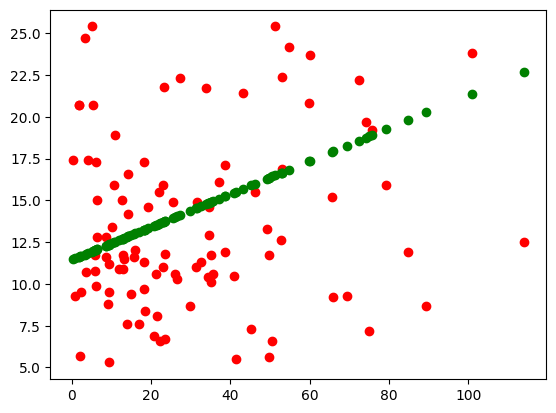

In [10]:
tvLm = smf.ols(formula= "sales ~ newspaper", data = trainData).fit()
tvLm.summary()

salesPredict = tvLm.predict(testData)
tvLm.summary()
plt.scatter(testData['newspaper'], testData['sales'], color = 'red')
plt.scatter(testData['newspaper'], salesPredict, color = 'green')
tvLm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     13.22
Date:                Sat, 16 May 2026   Prob (F-statistic):           0.000444
Time:                        18:18:50   Log-Likelihood:                -301.36
No. Observations:                 100   AIC:                             606.7
Df Residuals:                      98   BIC:                             611.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.4403      0.980     11.674      0.000       9.496      13.385
newspaper      0.0986      0.027      3.636      0.000       0.045       0.152
==============================================================================
Omnibus:                        2.465   Durbin-Watson:                   2.189
Prob(Omnibus):                  0.292   Jarque-Bera (JB):                1.843
Skew:                           0.156   Prob(JB):                        0.398
Kurtosis:                       2.412   Cond. No.                         71.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

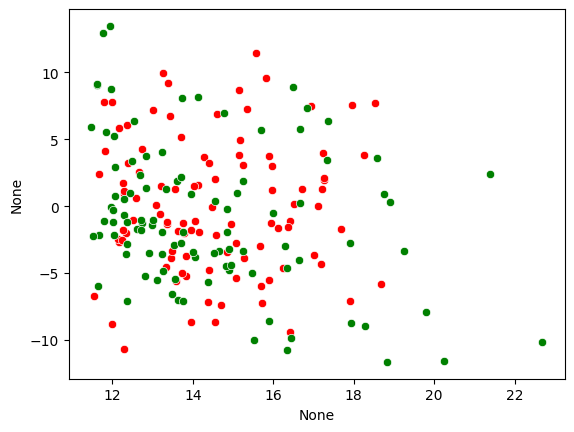

In [12]:
tvLm = smf.ols(formula= "sales ~ newspaper", data = trainData).fit()
tvLm.summary()

testPredict = tvLm.predict(testData)
trainPredict = tvLm.predict(trainData)
trainResiduals = trainData["sales"]-trainPredict
testResiduals = testData["sales"]-testPredict
tvLm.summary()
sns.scatterplot(x=trainPredict, y=trainResiduals, color = 'red')
sns.scatterplot(x=testPredict, y=testResiduals, color = 'green')
tvLm.summary()